# **Customer Churn Prediction (Classification)**


 # Problem Statement:

Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:

● Customer Age

● Gender

● Tenure

● Monthly Charges

● Total Charges

● Contract Type

● Payment Method

● Internet Service

● Tech Support

● Online Security

● Customer Support Calls

Students are required to analyze the dataset, preprocess the data, perform feature engineering, train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.


# Objective of this task is to:

● Understand and explore the customer dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv('/content/telecom_churn_data.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Basic checks.

Check for missing values.


In [ ]:
# check no. of rows and columns
data.shape

(7043, 21)

**The dataset hass 7043 rows and 21 columns .**

In [ ]:
# first 5 rows
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
# last 5 rows
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# check info : memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
# print numercial columns
num_colms= data.select_dtypes(include=['int64','float64'])
print(num_colms)

      SeniorCitizen  tenure  MonthlyCharges
0                 0       1           29.85
1                 0      34           56.95
2                 0       2           53.85
3                 0      45           42.30
4                 0       2           70.70
...             ...     ...             ...
7038              0      24           84.80
7039              0      72          103.20
7040              0      11           29.60
7041              1       4           74.40
7042              0      66          105.65

[7043 rows x 3 columns]


In [ ]:
# print only categorical columns
cat_colms= data.select_dtypes(include='object')
print(cat_colms)

      customerID  gender Partner Dependents PhoneService     MultipleLines  \
0     7590-VHVEG  Female     Yes         No           No  No phone service   
1     5575-GNVDE    Male      No         No          Yes                No   
2     3668-QPYBK    Male      No         No          Yes                No   
3     7795-CFOCW    Male      No         No           No  No phone service   
4     9237-HQITU  Female      No         No          Yes                No   
...          ...     ...     ...        ...          ...               ...   
7038  6840-RESVB    Male     Yes        Yes          Yes               Yes   
7039  2234-XADUH  Female     Yes        Yes          Yes               Yes   
7040  4801-JZAZL  Female     Yes        Yes           No  No phone service   
7041  8361-LTMKD    Male     Yes         No          Yes               Yes   
7042  3186-AJIEK    Male      No         No          Yes                No   

     InternetService OnlineSecurity OnlineBackup DeviceProtecti

In [ ]:
# check data types  of each colums
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#find the statistical report numercial data
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# find statistical report of categorical data
data.describe(include ='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7038,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7041,7043,7038,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6526,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3550,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4169,2365,11,5174


In [ ]:
# find unique / distinct values
for x in cat_colms:
    print(x,'--->',data[x].unique())

customerID ---> ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ---> ['Female' 'Male' nan]
Partner ---> ['Yes' 'No']
Dependents ---> ['No' 'Yes']
PhoneService ---> ['No' 'Yes']
MultipleLines ---> ['No phone service' 'No' 'Yes']
InternetService ---> ['DSL' 'Fiber optic' 'No']
OnlineSecurity ---> ['No' 'Yes' 'No internet service']
OnlineBackup ---> ['Yes' 'No' 'No internet service']
DeviceProtection ---> ['No' 'Yes' 'No internet service']
TechSupport ---> ['No' 'Yes' 'No internet service']
StreamingTV ---> ['No' 'Yes' 'No internet service']
StreamingMovies ---> ['No' 'Yes' 'No internet service']
Contract ---> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ---> ['Yes' 'No' nan]
PaymentMethod ---> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges ---> ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn ---> ['No' 'Yes']


In [ ]:
# find unique / distinct values
for x in num_colms:
    print(x,'--->',data[x].unique())

SeniorCitizen ---> [0 1]
tenure ---> [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
MonthlyCharges ---> [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]


In [ ]:
# find value count of each
for x in cat_colms:
    print(data[x].value_counts())
    print()

customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
Male      3550
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes      

In [ ]:
# find value count of each
for x in num_colms:
    print(data[x].value_counts())
    print()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

MonthlyCharges
20.05     61
19.85     45
19.95     44
19.90     44
19.70     43
          ..
53.70      1
51.50      1
72.20      1
102.25     1
87.75      1
Name: count, Length: 1585, dtype: int64



In [ ]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# Data cleaning.

# **How to handle missing values.**

1. Can we drop missing values .
- we can drop missing values if there are few values missing.
- Dropping missing is not recommended
when huge values are missing as it results in loss of information.
- Drop the column when % of missing values is greater than 70%.
2. Can we replace them with values
- We can use domain knoweledge and replace.
- We can replace with either mean or median or mode.
3. When to use mode.
- Use mode when categorical /text data is missing.
4. When to use mean or median.
- use when missing values is numerical.
- use mean when data distribution is  normal.
- use meadian when data distribution is skewed(left/right skewed).

gender

In [ ]:
#check the data type.
data.loc[: , "gender"].dtype

dtype('O')

clearely data type  of gender ids object.

In [ ]:
# If data type is object use mode
# find mode
data.loc[:,"gender"].mode()[0]

'Male'

In [ ]:
#use fillna to replcae
data.loc[:,"gender"]=data.loc[:,"gender"].fillna(data.loc[:,"gender"].mode()[0])

In [ ]:
#check
data.loc[:,"gender"].isnull().sum()

np.int64(0)

**PaperlessBillling.**

In [ ]:
#check the data type.
data.loc[: , "PaperlessBilling"].dtype

dtype('O')

In [ ]:
# If data type is object use mode
# find mode
data.loc[:,"PaperlessBilling"].mode()[0]

'Yes'

In [ ]:
#use fillna to replcae
data.loc[:,"PaperlessBilling"]=data.loc[:,"PaperlessBilling"].fillna(data.loc[:,"PaperlessBilling"].mode()[0])

In [ ]:
#check
data.loc[:,"PaperlessBilling"].isnull().sum()

np.int64(0)

**MonthlyCharges**

In [ ]:
#check the datatype
#check the data type.
data.loc[: , "MonthlyCharges"].dtypes

dtype('float64')

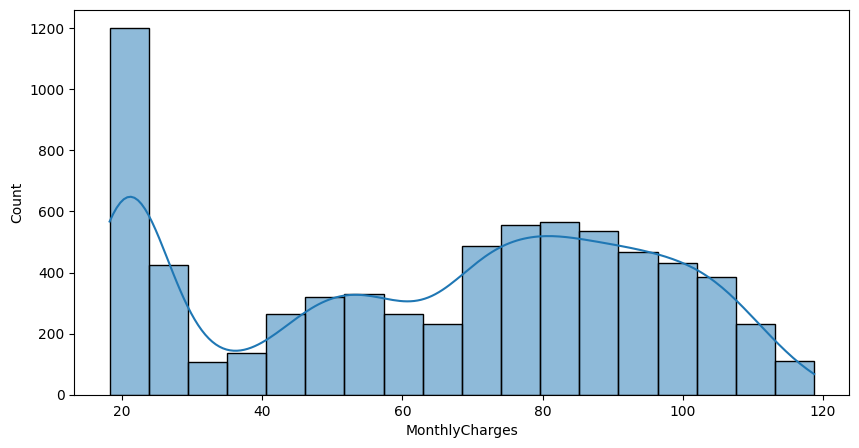

In [ ]:
#check the disatribution.
plt.figure(figsize=(10,5))
sns.histplot(data,x='MonthlyCharges',kde=True)
plt.show()


In [ ]:
# find skew
#skew : [-0.5,0.5]--> its normal
#skew > 0.5--> right skew
##skew < - 0.5--> left skew
data.loc[:,"MonthlyCharges"].skew()

np.float64(-0.22028439456532767)

In [ ]:
# The distribution is normal
#find mean
data.loc[:,"MonthlyCharges"].mean()

np.float64(64.74958102542253)

In [ ]:
# fill with mean
data.loc[:,"MonthlyCharges"]=data.loc[:,"MonthlyCharges"].fillna(data.loc[:,"MonthlyCharges"].mean())

**TotalCharges.**

In [ ]:
data.loc[:,"TotalCharges"].dtype

dtype('O')

Data type of total cxharge is incorrect.
Values within TotalCharges are numeric but data type is object which is wrong.

**Type casting**

Convert one data type into other format

- **as_type** : Used to when column doesn't have missisng values
- **pd.to_numeric** : Use this when column has missing values

In [ ]:
data.loc[:,'Total_Charges'] =pd.to_numeric(data.loc[:,'TotalCharges'],errors='coerce')

In [ ]:
data.drop(columns='TotalCharges',inplace=True)

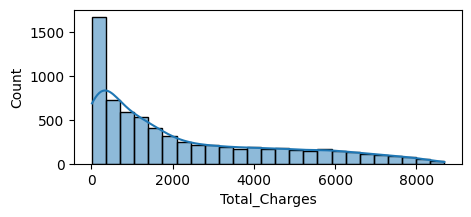

In [ ]:
# check distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='Total_Charges',kde=True)
plt.show()

In [ ]:
# check skewness
data.loc[:,"Total_Charges"].skew()

np.float64(0.9616058347613503)

In [ ]:
#Distribution is right skewed
# find median
data.loc[:,"Total_Charges"].median()

1397.3

In [ ]:
#fill with median
data.loc[:,"Total_Charges"]=data.loc[:,"Total_Charges"].fillna(data.loc[:,"Total_Charges"].median())

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data.duplicated().sum()

np.int64(0)

#**EDA**

In [ ]:
data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,29.85
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,No,1889.50
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,108.15
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,1840.75
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No,1990.50
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No,7362.90
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No,346.45
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes,306.60


#UNIVARIATE

# SeniorCitizen:
 is having int datatype but still it is not suitable for histplot visualization.
Because in that 1 is yes , 0 is no.

#tenure

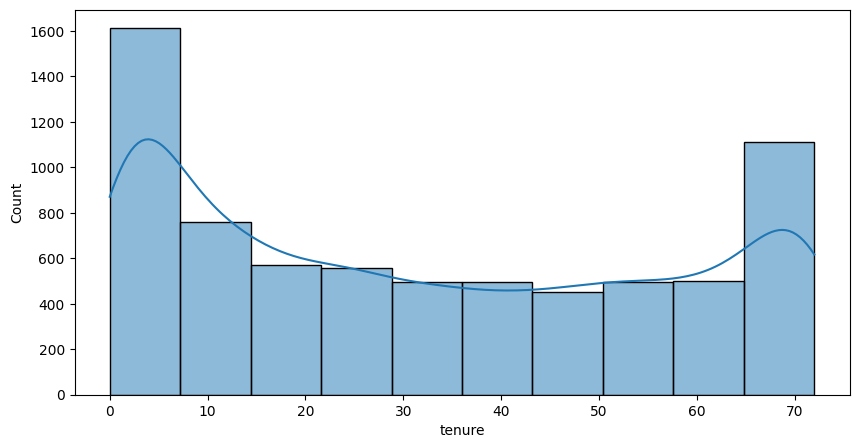

In [ ]:
# Distribution of tenure
plt.figure(figsize=(10,5))
sns.histplot(data,x='tenure',kde=True,bins=10)
plt.show()
# kde = that blue line.
# bins = no. of rectangle boxes.
# how along an employee gas worked in the company.

#MonthlyCharges

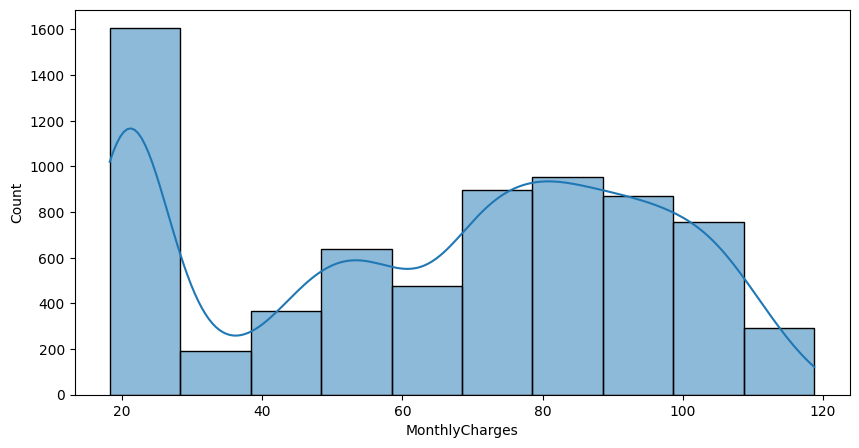

In [ ]:
# Distribution of MonthlyCharges
plt.figure(figsize=(10,5))
sns.histplot(data,x='MonthlyCharges',kde=True,bins=10)
plt.show()

#Total_Charges

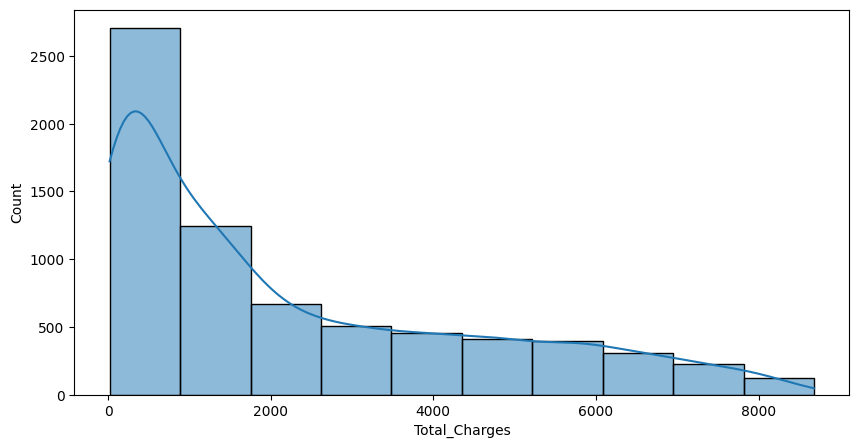

In [ ]:
# Distribution of Total_Charges
plt.figure(figsize=(10,5))
sns.histplot(data,x='Total_Charges',kde=True,bins=10)
plt.show()

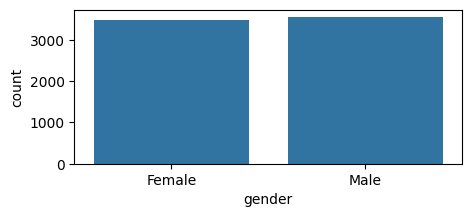

In [ ]:
 # Visualise count of male and female
# Visualise count of gender
plt.figure(figsize=(5,2))
sns.countplot(data,x='gender')
plt.show()

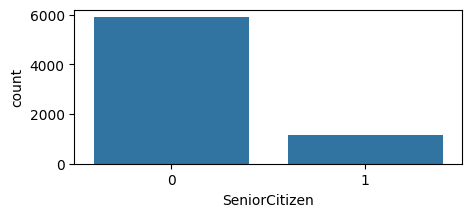

In [ ]:
# Visualise count of SeniorCitizen
plt.figure(figsize=(5,2))
sns.countplot(data,x='SeniorCitizen')
plt.show()

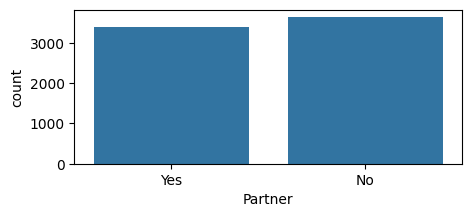

In [ ]:
# Visualise count of Partner
plt.figure(figsize=(5,2))
sns.countplot(data,x='Partner')
plt.show()

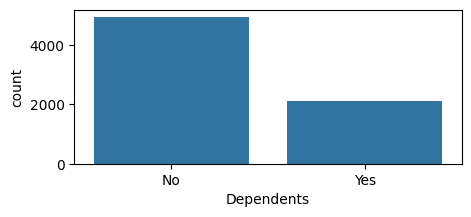

In [ ]:
# Visualise count of Dependents
plt.figure(figsize=(5,2))
sns.countplot(data,x='Dependents')
plt.show()

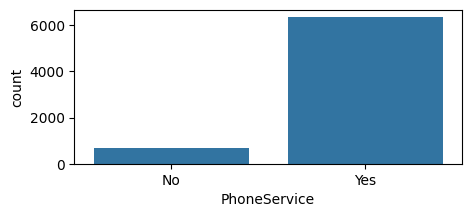

In [ ]:
# Visualise count of PhoneService
plt.figure(figsize=(5,2))
sns.countplot(data,x='PhoneService')
plt.show()

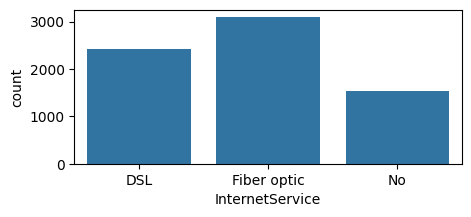

In [ ]:
# Visualise count of InternetService
plt.figure(figsize=(5,2))
sns.countplot(data,x='InternetService')
plt.show()

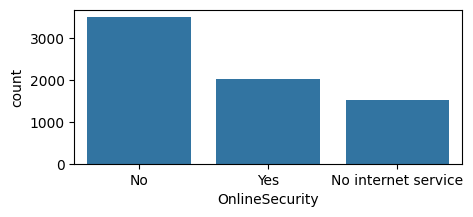

In [ ]:
# Visualise count of OnlineSecurity
plt.figure(figsize=(5,2))
sns.countplot(data,x='OnlineSecurity')
plt.show()

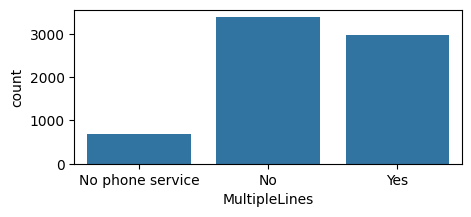

In [ ]:
# Visualise count of MultipleLines
plt.figure(figsize=(5,2))
sns.countplot(data,x='MultipleLines')
plt.show()

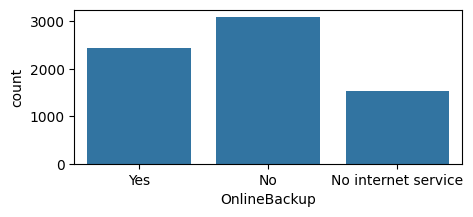

In [ ]:
# Visualise count of OnlineBackup
plt.figure(figsize=(5,2))
sns.countplot(data,x='OnlineBackup')
plt.show()

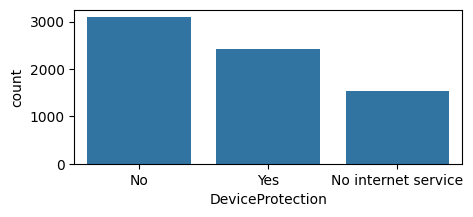

In [ ]:
# Visualise count of DeviceProtection
plt.figure(figsize=(5,2))
sns.countplot(data,x='DeviceProtection')
plt.show()

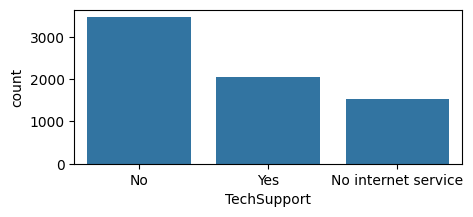

In [ ]:
# Visualise count of TechSupport
plt.figure(figsize=(5,2))
sns.countplot(data,x='TechSupport')
plt.show()

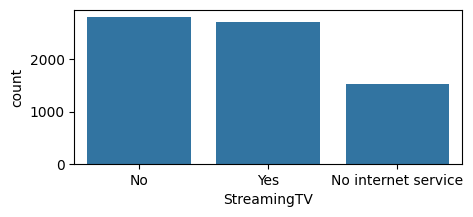

In [ ]:
# Visualise count of StrweamingTV
plt.figure(figsize=(5,2))
sns.countplot(data,x='StreamingTV')
plt.show()

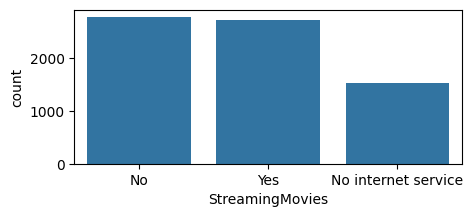

In [ ]:
# Visualise count of StreamingMovies
plt.figure(figsize=(5,2))
sns.countplot(data,x='StreamingMovies')
plt.show()

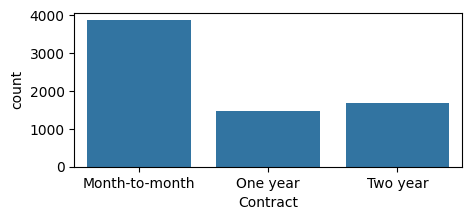

In [ ]:
# Visualise count of Contract
plt.figure(figsize=(5,2))
sns.countplot(data,x='Contract')
plt.show()

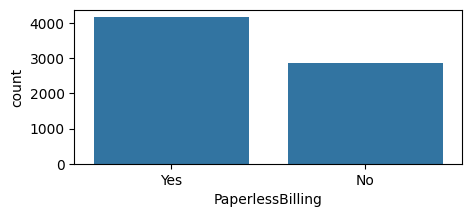

In [ ]:
# Visualise count of PaperlessBilling
plt.figure(figsize=(5,2))
sns.countplot(data,x='PaperlessBilling')
plt.show()

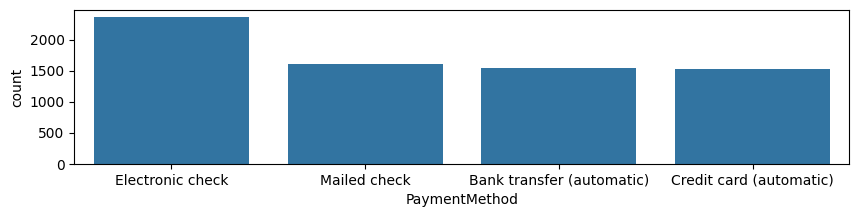

In [ ]:
# Visualise count of PaymentMethod
plt.figure(figsize=(10,2))
sns.countplot(data,x='PaymentMethod')
plt.show()

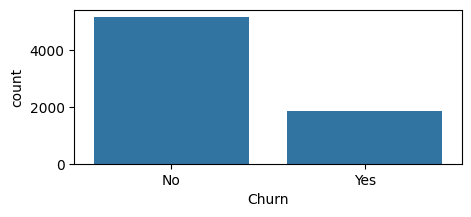

In [ ]:
# Visualise count of Churn
plt.figure(figsize=(5,2))
sns.countplot(data,x='Churn')
plt.show()

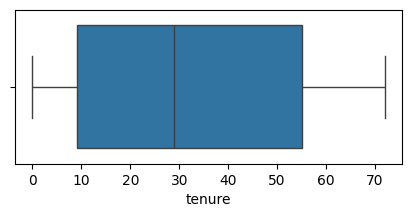

In [ ]:
# check outliers in tenure
plt.figure(figsize=(5,2))
sns.boxplot(data,x='tenure')
plt.show()

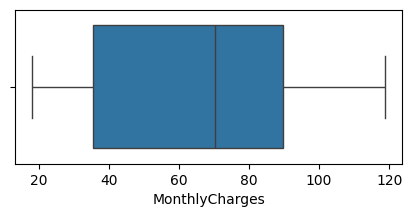

In [ ]:
# check outliers in MonthlyCharges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='MonthlyCharges')
plt.show()

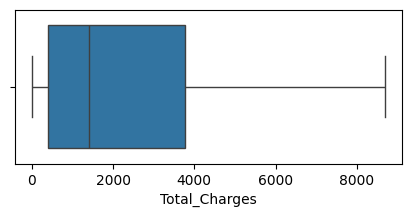

In [ ]:
# check outliers in Total_Charges
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Total_Charges')
plt.show()

# BIVARIATE

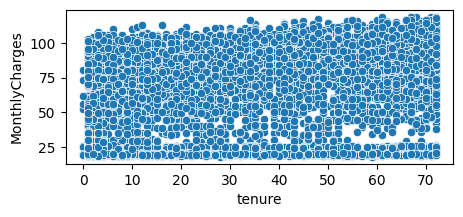

In [ ]:
# check the relationship tenure & Monthly Charges.
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='tenure',y='MonthlyCharges')
plt.show()

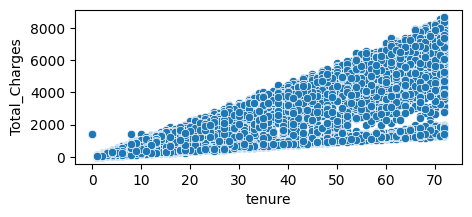

In [ ]:
# check the relationship between tenure  and totalcharges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='tenure',y='Total_Charges')
plt.show()


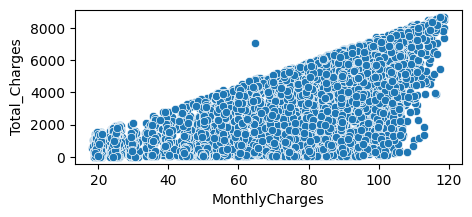

In [ ]:
# check the relationship between monthlycharges and total charges
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='MonthlyCharges',y='Total_Charges')

plt.show()

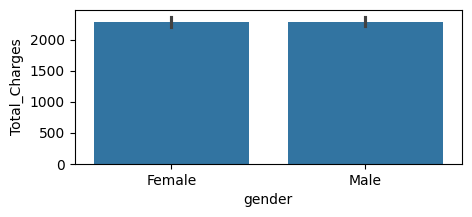

In [ ]:
# Compare how total charges vary with gender
plt.figure(figsize=(5,2))
sns.barplot(data,x='gender',y='Total_Charges')
plt.show()

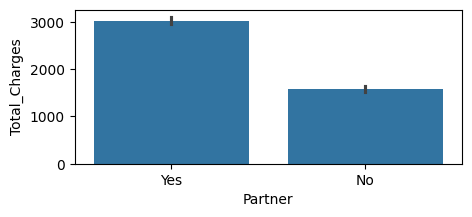

In [ ]:
# Compare how total charges vary with partner
plt.figure(figsize=(5,2))
sns.barplot(data,x='Partner',y='Total_Charges')
plt.show()

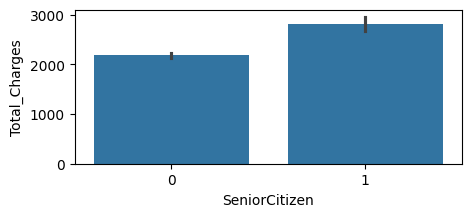

In [ ]:
# Compare how totalcharges vary with SenioCitizen
plt.figure(figsize=(5,2))
sns.barplot(data,x='SeniorCitizen',y='Total_Charges')
plt.show()

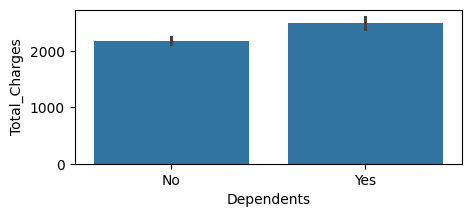

In [ ]:
# Compare how totalcharges vary with dependents
plt.figure(figsize=(5,2))
sns.barplot(data,x='Dependents',y='Total_Charges')
plt.show()

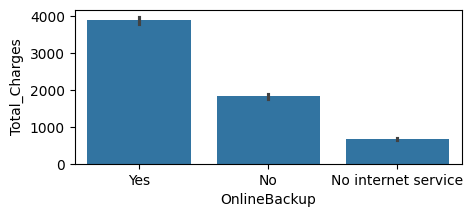

In [ ]:
# Compare how totalcharges vary with Onlinebackup
plt.figure(figsize=(5,2))
sns.barplot(data,x='OnlineBackup',y='Total_Charges')
plt.show()

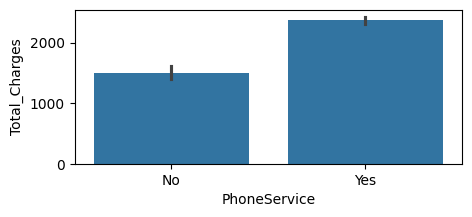

In [ ]:
# Compare how totalcharges vary with phoneservice
plt.figure(figsize=(5,2))
sns.barplot(data,x='PhoneService',y='Total_Charges')
plt.show()

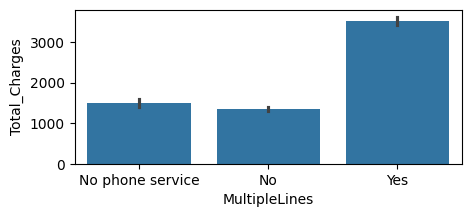

In [ ]:
# Compare how totalcharges vary with multiplepipes
plt.figure(figsize=(5,2))
sns.barplot(data,x='MultipleLines',y='Total_Charges')
plt.show()

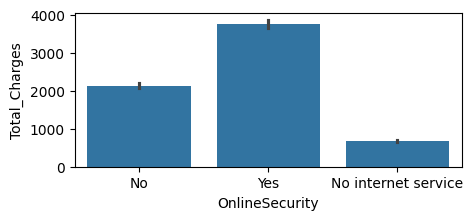

In [ ]:
# Compare how totalcharges vary with onlinesecurity
plt.figure(figsize=(5,2))
sns.barplot(data,x='OnlineSecurity',y='Total_Charges')
plt.show()

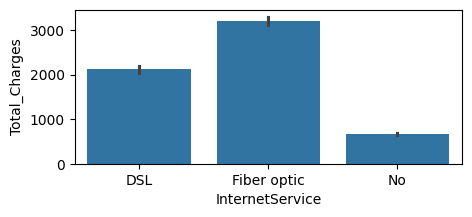

In [ ]:
# Compare how totalcharges vary with internetservice
plt.figure(figsize=(5,2))
sns.barplot(data,x='InternetService',y='Total_Charges')
plt.show()

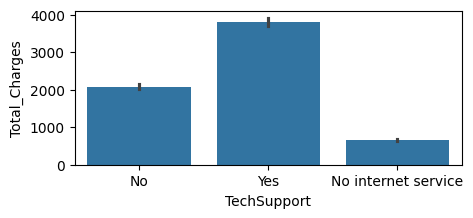

In [ ]:
# Compare how totalcharges vary with techsupport
plt.figure(figsize=(5,2))
sns.barplot(data,x='TechSupport',y='Total_Charges')
plt.show()

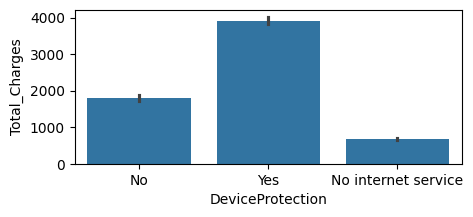

In [ ]:
# Compare how totalcharges vary with DeviceProtection
plt.figure(figsize=(5,2))
sns.barplot(data,x='DeviceProtection',y='Total_Charges')
plt.show()

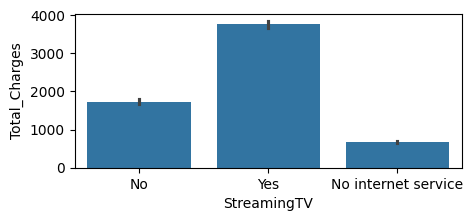

In [ ]:
# Compare how totalcharges vary with streamingtv
plt.figure(figsize=(5,2))
sns.barplot(data,x='StreamingTV',y='Total_Charges')
plt.show()

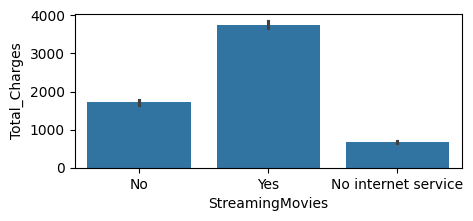

In [ ]:
# Compare how total charges vary with Streamingmovies
plt.figure(figsize=(5,2))
sns.barplot(data,x='StreamingMovies',y='Total_Charges')
plt.show()

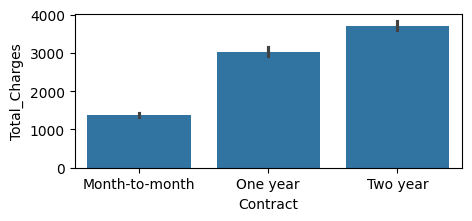

In [ ]:
# Compare how totalcharges  vary with contract
plt.figure(figsize=(5,2))
sns.barplot(data,x='Contract',y='Total_Charges')
plt.show()

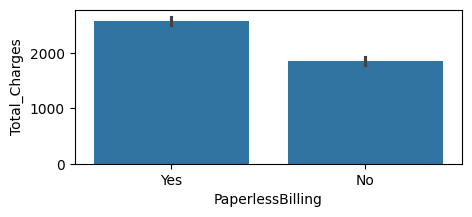

In [ ]:
# Compare how totalcharges vary with paperlessbilling
plt.figure(figsize=(5,2))
sns.barplot(data,x='PaperlessBilling',y='Total_Charges')
plt.show()

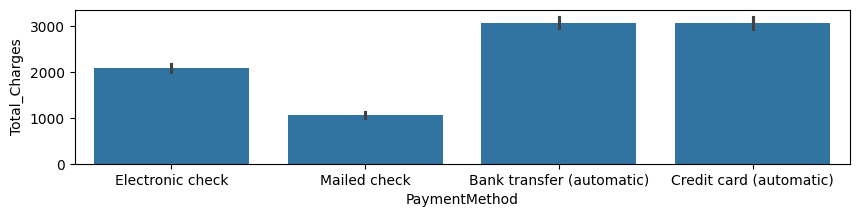

In [ ]:
# Compare how Total_charges vary with PaymentCharges
plt.figure(figsize=(10,2))
sns.barplot(data,x='PaymentMethod',y='Total_Charges')
plt.show()

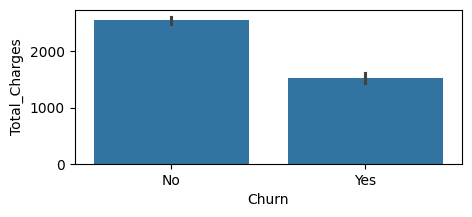

In [ ]:
# Compare how TotalCharges vary with Churn
plt.figure(figsize=(5,2))
sns.barplot(data,x='Churn',y='Total_Charges')
plt.show()

# MULTIVARIATE

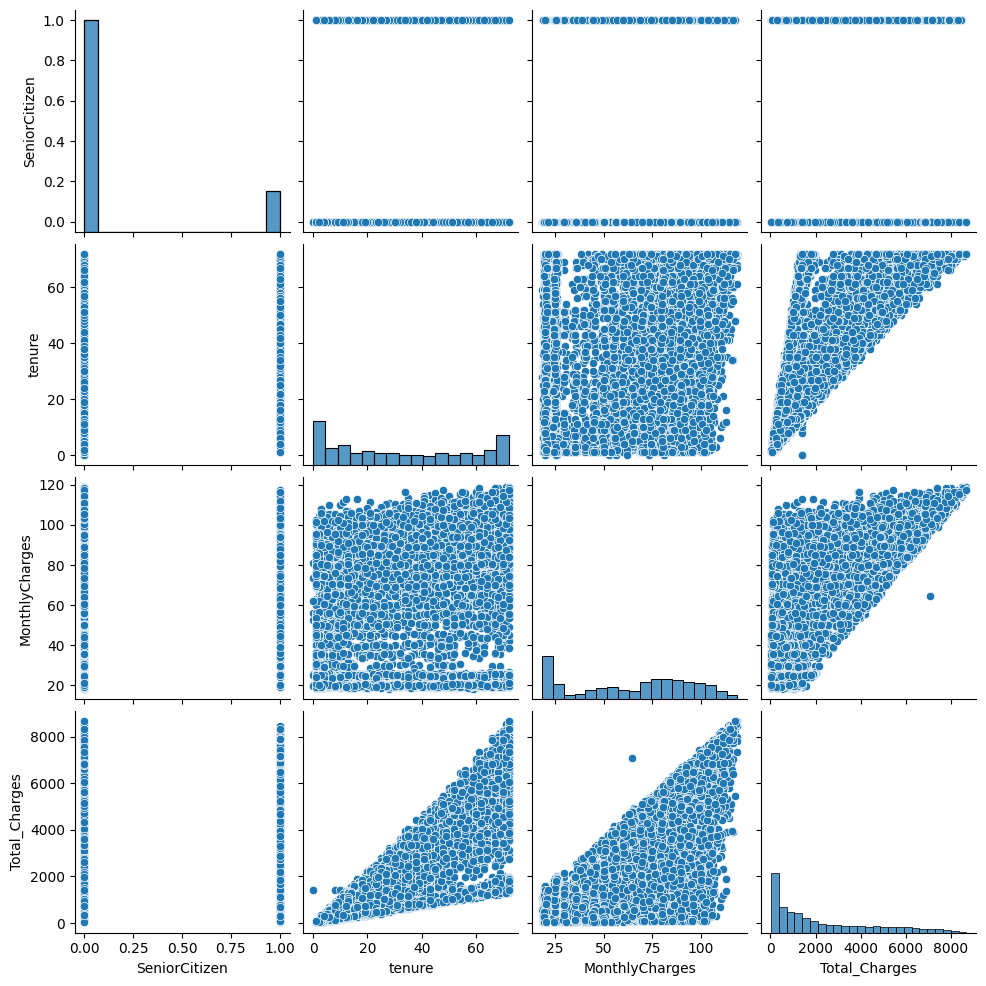

In [ ]:
# pairplot: It creates scatter plot among all the numerical variables
sns.pairplot(data)

In [ ]:

# Correlation measures how strong two variables

num_colms = data.select_dtypes(include=['int64','float64'])
display(num_colms.corr())

,SeniorCitizen,tenure,MonthlyCharges,Total_Charges
SeniorCitizen,1.000000,0.016567,0.219854,0.102759
tenure,0.016567,1.000000,0.247675,0.825339
MonthlyCharges,0.219854,0.247675,1.000000,0.650393
Total_Charges,0.102759,0.825339,0.650393,1.000000


<Axes: >

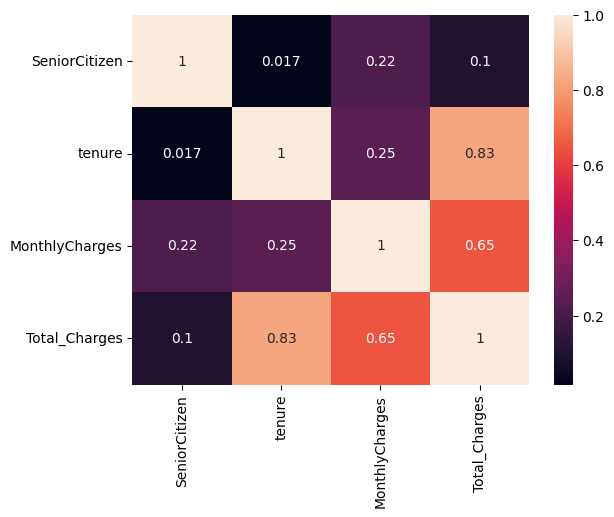

In [ ]:
# heat map : Used to visualise the correlation
sns.heatmap(num_colms.corr(),annot=True)
#annot = display the no. , it is used only in heatmaps,
# annot = true , display cplour & values, if false no numbers.

#Handle outliers

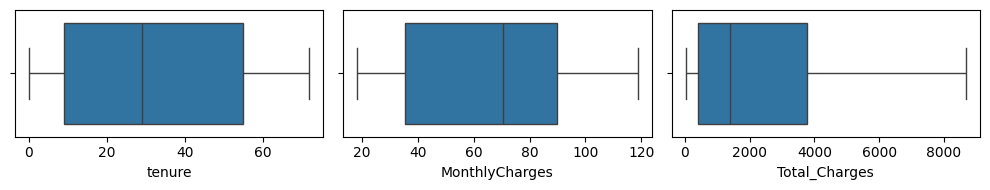

In [ ]:
fig,ax = plt.subplots(1,3,figsize=(10,2))
sns.boxplot(data,x='tenure',ax=ax[0])
sns.boxplot(data,x='MonthlyCharges',ax=ax[1])
sns.boxplot(data,x='Total_Charges',ax=ax[2])
plt.tight_layout()

 There are no outliers in tenure, monthly charges & Total Charges

FIND OUTLIERS

**Check the distribution of tenure , monthly charges , total charges.**

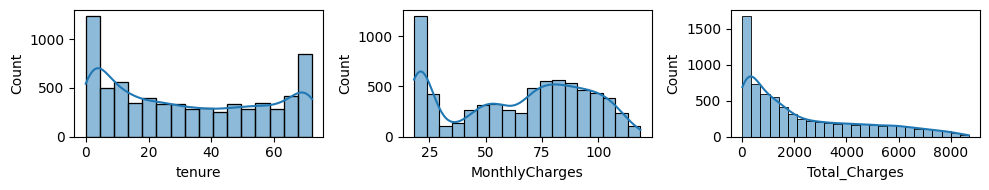

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(10,2))
sns.histplot(data,x='tenure',ax=ax[0],kde=True)
sns.histplot(data,x='MonthlyCharges',ax=ax[1],kde=True)
sns.histplot(data,x='Total_Charges',ax=ax[2],kde=True)
plt.tight_layout()

Find Skew

In [ ]:
data["tenure"].skew()

np.float64(0.2395397495619829)

this is normal deistribution

In [ ]:
# loc is used to get all rows of mentioned column.
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22031566496415986)

this is normal distribution

In [ ]:
data.loc[:,'Total_Charges'].skew()

np.float64(0.9647294463449093)

this is right skewd

#  IQR Method for Total_Charges.

In [ ]:
Q1 = data.loc[:,'Total_Charges'].quantile(0.25)
Q3 = data.loc[:,'Total_Charges'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
# filter all the values greater than upper_limit
data[data.loc[:,'Total_Charges']>upper_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# filter values less than lower_limit
data[data.loc[:,'Total_Charges']<lower_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# percentage of outliers
len(data[(data.loc[:,'Total_Charges']>upper_limit)|(data.loc[:,'Total_Charges']<lower_limit)
])/len(data)*100

0.0

In [ ]:
data.loc[data.loc[:,'Total_Charges']>upper_limit,'Total_Charges']= data.loc[:,'Total_Charges'].median()

3 Sigma rule for  tenure and monthly charges , beacuse the data is normally distributed.

In [ ]:
mean_val= data.loc[:,'tenure'].mean()
std_val =data.loc[:,'tenure'].std()
lower_limit = mean_val - 3*std_val
upper_limit = mean_val + 3*std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'tenure']>upper_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# filter values less than lower limit
data[data.loc[:,'tenure']<lower_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# find %
len(data[(data.loc[:,'tenure']>upper_limit)|(data.loc[:,'tenure']<lower_limit)])/len(data)*100

0.0

since % of outliers is less than 5% we need to replace them with mean.

In [ ]:
data.loc[data.loc[:,'tenure']>upper_limit,'tenure']= data.loc[:,'tenure'].mean()

/tmp/ipykernel_6427/1486617301.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '32.37114865824223' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.loc[:,'tenure']>upper_limit,'tenure']= data.loc[:,'tenure'].mean()


In [ ]:
data[data.loc[:,'tenure'] > upper_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# Monthly Charges
mean_val= data.loc[:,'MonthlyCharges'].mean()
std_val =data.loc[:,'MonthlyCharges'].std()
lower_limit = mean_val - 3*std_val
upper_limit = mean_val + 3*std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'MonthlyCharges']>upper_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# filter values less than lower limit
data[data.loc[:,'MonthlyCharges']<lower_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


In [ ]:
# find %
len(data[(data.loc[:,'MonthlyCharges']>upper_limit)|(data.loc[:,'MonthlyCharges']<lower_limit)])/len(data)*100

0.0

since % of outliers is less than 5% we need to replace them with mean.

In [ ]:
data.loc[data.loc[:,'MonthlyCharges']>upper_limit,'MonthlyCharges']= data.loc[:,'MonthlyCharges'].mean()

In [ ]:
data[data.loc[:,'MonthlyCharges'] > upper_limit]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges


# Encoding Techniques

**Label encoder**

In [ ]:
# gender
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'gender'] = le.fit_transform(data.loc[:,'gender'])

In [ ]:
# Partner
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Partner'] = le.fit_transform(data.loc[:,'Partner'])

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges
0,7590-VHVEG,0,0,1,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,29.85
1,5575-GNVDE,1,0,0,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,No,1889.50
2,3668-QPYBK,1,0,0,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,108.15
3,7795-CFOCW,1,0,0,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,1840.75
4,9237-HQITU,0,0,0,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,Yes,24.0,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,No,1990.50
7039,2234-XADUH,0,0,1,Yes,72.0,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,No,7362.90
7040,4801-JZAZL,0,0,1,Yes,11.0,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,No,346.45
7041,8361-LTMKD,1,1,1,No,4.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,Yes,306.60


In [ ]:
# Dependents
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'Dependents']= le.fit_transform(data.loc[:,'Dependents'])

In [ ]:
# Phoneservice
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"PhoneService"]=le.fit_transform(data.loc[:,"PhoneService"])

In [ ]:
## Multilelines
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"MultipleLines"]=le.fit_transform(data.loc[:,"MultipleLines"])

In [ ]:
# InternetService
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"InternetService"]=le.fit_transform(data.loc[:,"InternetService"])

In [ ]:
## OnlineSecurity
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"OnlineSecurity"]=le.fit_transform(data.loc[:,"OnlineSecurity"])

In [ ]:
#OnlineBackup
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"OnlineSecurity"]=le.fit_transform(data.loc[:,"OnlineSecurity"])

In [ ]:
## Phoneservice
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"OnlineBackup"]=le.fit_transform(data.loc[:,"OnlineBackup"])

In [ ]:
##DeviceProtection
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"DeviceProtection"]=le.fit_transform(data.loc[:,"DeviceProtection"])

In [ ]:
## TechSupport
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"TechSupport"]=le.fit_transform(data.loc[:,"TechSupport"])

In [ ]:
## StreamingTV
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"StreamingTV"]=le.fit_transform(data.loc[:,"StreamingTV"])

In [ ]:
## StreamingMovies
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"StreamingMovies"]=le.fit_transform(data.loc[:,"StreamingMovies"])

In [ ]:
## Contract
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"Contract"]=le.fit_transform(data.loc[:,"Contract"])

In [ ]:
## PaperlessBilling
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"PaperlessBilling"]=le.fit_transform(data.loc[:,"PaperlessBilling"])

In [ ]:
## Churn
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data.loc[:,"Churn"]=le.fit_transform(data.loc[:,"Churn"])

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges
0,7590-VHVEG,0,0,1,0,1.0,0,1,0,0,...,0,0,0,0,0,1,Electronic check,29.85,0,29.85
1,5575-GNVDE,1,0,0,0,34.0,1,0,0,2,...,2,0,0,0,1,0,Mailed check,56.95,0,1889.50
2,3668-QPYBK,1,0,0,0,2.0,1,0,0,2,...,0,0,0,0,0,1,Mailed check,53.85,1,108.15
3,7795-CFOCW,1,0,0,0,45.0,0,1,0,2,...,2,2,0,0,1,0,Bank transfer (automatic),42.30,0,1840.75
4,9237-HQITU,0,0,0,0,2.0,1,0,1,0,...,0,0,0,0,0,1,Electronic check,70.70,1,151.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24.0,1,2,0,2,...,2,2,2,2,1,1,Mailed check,84.80,0,1990.50
7039,2234-XADUH,0,0,1,1,72.0,1,2,1,0,...,2,0,2,2,1,1,Credit card (automatic),103.20,0,7362.90
7040,4801-JZAZL,0,0,1,1,11.0,0,1,0,2,...,0,0,0,0,0,1,Electronic check,29.60,0,346.45
7041,8361-LTMKD,1,1,1,0,4.0,1,2,1,0,...,0,0,0,0,0,1,Mailed check,74.40,1,306.60


# One Hot Encoding Techniques

In [ ]:
# Gender - One hot encoding
# Contract - order matters
# Property_Area - target encoding

In [ ]:
data = pd.get_dummies(data,columns=['gender'],dtype='int')
data

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges,gender_0,gender_1
0,7590-VHVEG,0,1,0,1.0,0,1,0,0,2,...,0,0,0,1,Electronic check,29.85,0,29.85,1,0
1,5575-GNVDE,0,0,0,34.0,1,0,0,2,0,...,0,0,1,0,Mailed check,56.95,0,1889.50,0,1
2,3668-QPYBK,0,0,0,2.0,1,0,0,2,2,...,0,0,0,1,Mailed check,53.85,1,108.15,0,1
3,7795-CFOCW,0,0,0,45.0,0,1,0,2,0,...,0,0,1,0,Bank transfer (automatic),42.30,0,1840.75,0,1
4,9237-HQITU,0,0,0,2.0,1,0,1,0,0,...,0,0,0,1,Electronic check,70.70,1,151.65,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,1,1,24.0,1,2,0,2,0,...,2,2,1,1,Mailed check,84.80,0,1990.50,0,1
7039,2234-XADUH,0,1,1,72.0,1,2,1,0,2,...,2,2,1,1,Credit card (automatic),103.20,0,7362.90,1,0
7040,4801-JZAZL,0,1,1,11.0,0,1,0,2,0,...,0,0,0,1,Electronic check,29.60,0,346.45,1,0
7041,8361-LTMKD,1,1,0,4.0,1,2,1,0,0,...,0,0,0,1,Mailed check,74.40,1,306.60,0,1


Ordinal encoder

In [ ]:
# Contract
data.loc[:,'Contract']=data.loc[:,'Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})

Target Encoder

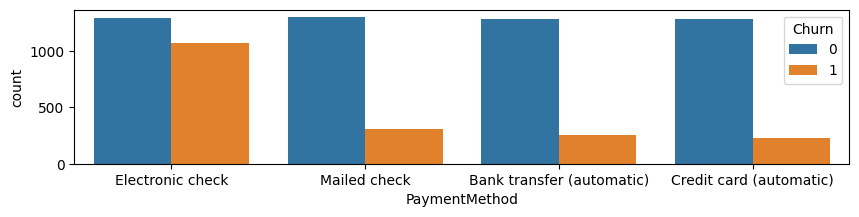

In [ ]:
# PaymentMethod
plt.figure(figsize=(10,2))
sns.countplot(data,x='PaymentMethod',hue='Churn')
plt.show()

In [ ]:
data.loc[:,'PaymentMethod'] = data.loc[:,'PaymentMethod'].map(
    {"Credit card (automatic)":3,'Bank transfer (automatic)':2,'Mailed check':1,'Electornic check':0})

In [ ]:
# drop
data.drop(columns=['customerID'],inplace=True)

# FEATURE ENGINEERING.

#Scaling

In [ ]:
# standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data[['tenure']]= scaler.fit_transform(data[['tenure']])
data[['MonthlyCharges']]= scaler.fit_transform(data[['MonthlyCharges']])
data[['Total_Charges']]= scaler.fit_transform(data[['Total_Charges']])

Log Transformation

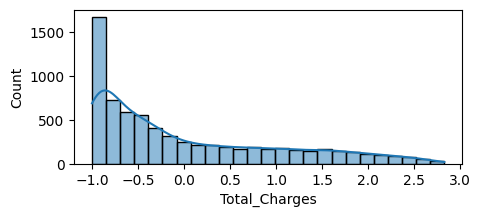

In [ ]:
# Total_Charges
plt.figure(figsize=(5,2))
sns.histplot(data, x='Total_Charges', kde = True)
plt.show()

In [ ]:
data.loc[:,"Total_Charges"]=np.log(data.loc[:,"Total_Charges"])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


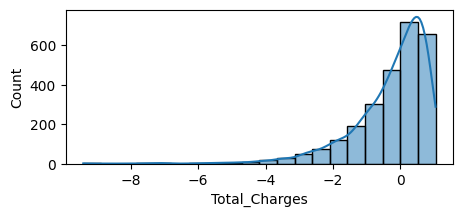

In [ ]:
# Total_Charges , after log transform
plt.figure(figsize=(5,2))
sns.histplot(data, x='Total_Charges', kde = True,bins=20)
plt.show()

In [ ]:
data["Total_Charges"].skew()

np.float64(-1.8942004183536545)

Splitting of data

# Split data for x & y

In [ ]:
x = data.drop(columns=['StreamingTV',"StreamingMovies","PhoneService"])
y=data['Churn'].astype(int)

# Split data for training & testing.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(5634, 18)

In [ ]:
x_test.shape

(1409, 18)

In [ ]:
# convert everything into numeric
x_train = x_train.apply(pd.to_numeric, errors='coerce')

# replace NaN if created
x_train = x_train.fillna(0)

# Balancing Data /SMOTE

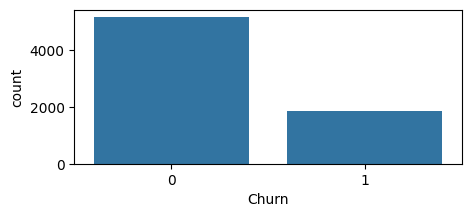

In [ ]:
# Balancing the data in the Chrun
plt.figure(figsize=(5,2))
sns.countplot(data,x='Churn')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)
# Balancing should be done only on training data.

In [ ]:
print('Counts of Churn in original training data:', Counter(y_train))
print('Counts of Churn in SMOTE-resampled training data:', Counter(y_sampled))

Counts of Churn in original training data: Counter({0: 4138, 1: 1496})
Counts of Churn in SMOTE-resampled training data: Counter({0: 4138, 1: 4138})


# Logistic Regression

In [ ]:
# convert everything into numeric
x_test= x_test.apply(pd.to_numeric, errors='coerce')

# replace NaN if created
x_test = x_test.fillna(0)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=5000)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
model.coef_

array([[-3.37777736e-02, -1.13238616e-01, -2.98209687e-01,
        -4.60373152e-01,  3.87017160e-02, -9.51011130e-04,
        -1.59026864e-01, -6.52442159e-02, -2.77951479e-02,
        -1.68543775e-01,  0.00000000e+00,  9.32773846e-02,
        -1.10072569e-01,  3.63390233e-01,  1.13079050e+01,
         1.03412624e-02, -3.10239996e-01, -2.98441868e-01]])

In [ ]:
model.intercept_

array([-5.06828528])

In [ ]:
model.predict_proba(x_test)

array([[2.34391047e-03, 9.97656090e-01],
       [9.98464959e-01, 1.53504130e-03],
       [9.99282491e-01, 7.17509277e-04],
       ...,
       [9.98738898e-01, 1.26110244e-03],
       [9.99333141e-01, 6.66858974e-04],
       [3.27229851e-03, 9.96727701e-01]])

# **Evaluate the model**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score,roc_curve, roc_auc_score

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1036,    0],
       [   0,  373]])

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
recall_score(y_test,y_pred)

1.0

In [ ]:
precision_score(y_test,y_pred)

1.0

In [ ]:
f1_score(y_test,y_pred)

1.0

In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob
# can be used only for classification.


array([9.97656090e-01, 1.53504130e-03, 7.17509277e-04, ...,
       1.26110244e-03, 6.66858974e-04, 9.96727701e-01])

In [ ]:
roc_auc_score(y_test,y_prob)

np.float64(1.0)

In [ ]:
fpr,tpr,threshold= roc_curve(y_test,y_prob)

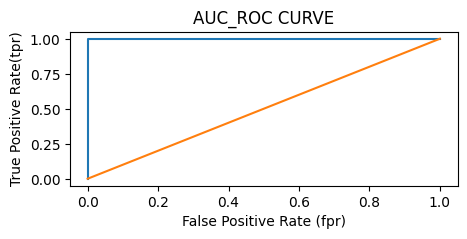

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate (fpr)")
plt.ylabel("True Positive Rate(tpr)")
plt.title("AUC_ROC CURVE")
plt.show()

In [ ]:
import pickle
with open('lgr_model.pkl','wb') as f:
  pickle.dump(model,f)

# KNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)


array([[1036,    0],
       [   0,  373]])

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
precision_score(y_test,y_pred)

1.0

In [ ]:
recall_score(y_test,y_pred)

1.0

In [ ]:
f1_score(y_test,y_pred)

1.0

In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob

array([9.97656090e-01, 1.53504130e-03, 7.17509277e-04, ...,
       1.26110244e-03, 6.66858974e-04, 9.96727701e-01])

# How to find k

In [ ]:
error =[]
for k in range(2,11):
  model= KNeighborsClassifier(n_neighbors=k)
  model.fit(x_sampled,y_sampled)
  y_pred = model.predict(x_test)
  error.append(np.mean(y_pred!=y_test))
print(error)

[np.float64(0.07877927608232789), np.float64(0.07026259758694109), np.float64(0.07026259758694109), np.float64(0.08090844570617459), np.float64(0.07026259758694109), np.float64(0.08658623136976579), np.float64(0.07594038325053229), np.float64(0.09297374024130589), np.float64(0.0801987224982257)]


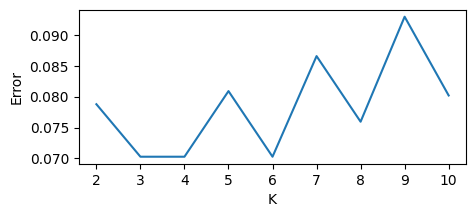

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel("K")
plt.ylabel("Error")
plt.show()

# Decision Tree classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_dt=DecisionTreeClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

array([[972,  64],
       [ 49, 324]])

In [ ]:
accuracy_score(y_test,y_pred)

0.9198012775017743

In [ ]:
precision_score(y_test,y_pred)

0.8350515463917526

In [ ]:
recall_score(y_test,y_pred)

0.868632707774799

In [ ]:
f1_score(y_test,y_pred)

0.8515111695137977

In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob

array([0.9, 0. , 0. , ..., 0. , 0.1, 1. ])

# DT with Hyperparameters

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion='gini',max_depth=50,max_features='sqrt',splitter='best',min_samples_leaf=6,min_samples_split=5

                        )
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
confusion_matrix(y_test,y_pred)

array([[972,  64],
       [ 29, 344]])

In [ ]:
accuracy_score(y_test,y_pred)

0.9339957416607523

In [ ]:
precision_score(y_test,y_pred)

0.8431372549019608

In [ ]:
recall_score(y_test,y_pred)

0.9222520107238605

In [ ]:
f1_score(y_test,y_pred)

0.8809218950064021

In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob

array([0.92857143, 0.        , 0.        , ..., 0.        , 0.14285714,
       1.        ])

# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)


In [ ]:
confusion_matrix(y_test,y_pred)

array([[1036,    0],
       [   0,  373]])

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
precision_score(y_test,y_pred)

1.0

In [ ]:
recall_score(y_test,y_pred)

1.0

In [ ]:
f1_score(y_test,y_pred)

1.0

In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob

array([0.98, 0.02, 0.  , ..., 0.  , 0.  , 0.95])

# RF Hyperparameters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,max_depth=10,criterion='gini',
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5
                               ,bootstrap=True)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


In [ ]:
y_prob= model.predict_proba(x_test)[:,1]
y_prob

array([0.9544335 , 0.        , 0.02666667, ..., 0.05555556, 0.        ,
       0.67769608])

# Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_sampled , y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# Hyperparamters

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(n_estimators=50,max_depth=10,
                                   max_features='sqrt',learning_rate=0.01,
                                   min_samples_split=5,min_samples_leaf=6)
model.fit(x_sampled , y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# XGBOOST Classifier


In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# Hyperparamters

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# K Fold Cross validation

In [ ]:
# u can apply cross validation process to any of the model . it os not specific only to XGB.
from sklearn.model_selection import KFold,StratifiedKFold,cross_val_score
model = XGBClassifier()
kf = KFold(n_splits=5,shuffle =True,random_state=42)
scores = cross_val_score(model ,x_sampled,y_sampled,cv=kf)
print(scores)
print(np.mean(scores))

[1. 1. 1. 1. 1.]
1.0


# Stratified K fold Cross validation

In [ ]:
model = XGBClassifier()
sf = StratifiedKFold(n_splits=5,shuffle =True,random_state=42)
scores = cross_val_score(model ,x_sampled,y_sampled,cv=sf)
print(scores)
print(np.mean(scores))
# KFold cross validation is better than stratified bez it doesnot ask for the class distrribution in each fold to be the same as the original classes.

[1. 1. 1. 1. 1.]
1.0


# Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='rbf',gamma=0.01,C=20)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# Hyperparameter Tuning Techniques
- The process of selecting best hyperparameters (learning paramters) used during the training to enhance the model performance.

- Grid Search Cv
- Randomized Search Cv

 **These techniques can be used with any models , not only SVM.**
  - **NOTE** : If u do hyperparameter tuning techniques for any model , then there is no requirement of the cross validation process.

# Grid Search Cv
- GS Cv trains the model with all the combinations of hyperparameters and selects the best one which performs really well.

In [ ]:
C = [5,10,20]
gamma = [0,0.1,0.01]
# grid search uses all the combinations


In [ ]:
from sklearn.model_selection import GridSearchCV
model = SVC()
parameters = {'kernel':['linear','poly','sigmoid','rbf'],
              'gamma':[0.1,0.2,0.01,0.02,0.3],'C':[5,10,15,20,25,30]}
grid = GridSearchCV(estimator=model , param_grid=parameters,cv=5,scoring='accuracy')
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [5, 10, 15, 20, 25, 30],
                         'gamma': [0.1, 0.2, 0.01, 0.02, 0.3],
                         'kernel': ['linear', 'poly', 'sigmoid', 'rbf']},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'C': 5, 'gamma': 0.1, 'kernel': 'linear'}


SCV

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear',gamma=0.1,C=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


In [ ]:
# XGBOOST

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=50,max_depth=10,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


In [ ]:
# xgboost
from sklearn.model_selection import GridSearchCV
model = XGBClassifier()
parameters = {'n_estimators':[5,10,30,50,100,200],
              'max_depth':[3,5,10,15],'gamma':[0.1,0.01,0.02,0.03],
              'learning_rate':[0.1,0.01],'reg_alpha':[0.1,0.01],
              'reg_lambda':[1,2,3]}
grid = GridSearchCV(estimator=model , param_grid=parameters,cv=5,scoring='accuracy')
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'gamma': [0.1, 0.01, 0.02, 0.03],
                         'learning_rate': [0.1, 0.01],
                         'max_depth': [3, 5, 10, 15],
                         'n_estimators': [5, 10, 30, 50, 100, 200],
                         'reg_alpha': [0.1, 0.01], 'reg_lambda': [1, 2, 3]},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 5, 'reg_alpha': 0.1, 'reg_lambda': 1}


In [ ]:
# For Hyperparameters of XGBoost We are going to apply new values that we have got after the Grid Search Cv.

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=5,max_depth=3,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# Evalaute the model
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# Randomized Search CV
It takes random combinations and selects the best among them

- Grid Search Cv is better than randomized search CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
model=SVC()
parameters = {'kernel':['linear','poly','sigmoid','rbf'],
              'gamma':[0.1,0.2,0.01,0.02,0.3],'C':[5,10,15,20,25,30]}# For the best result u should increase the parameters value still more.
random = RandomizedSearchCV(estimator=model , param_distributions=parameters,
                            cv=5,scoring='accuracy',n_iter=20)
random.fit(x_sampled,y_sampled)


RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=20,
                   param_distributions={'C': [5, 10, 15, 20, 25, 30],
                                        'gamma': [0.1, 0.2, 0.01, 0.02, 0.3],
                                        'kernel': ['linear', 'poly', 'sigmoid',
                                                   'rbf']},
                   scoring='accuracy')

In [ ]:
print(random.best_params_)

{'kernel': 'poly', 'gamma': 0.02, 'C': 15}


SVC

In [ ]:
from sklearn.svm import SVC
model = SVC(kernel='linear',gamma=0.02,C=10)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
print("Confusion_matrix \n",confusion_matrix(y_test,y_pred))
print("Accuracy score: ",accuracy_score(y_test,y_pred))
print("Precision score: ",precision_score(y_test,y_pred))
print("Recall score: ",recall_score(y_test,y_pred))
print("f1 score: ",f1_score(y_test,y_pred))

Confusion_matrix 
 [[1036    0]
 [   0  373]]
Accuracy score:  1.0
Precision score:  1.0
Recall score:  1.0
f1 score:  1.0


# Compare model performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Dictionary to store all model results
all_model_results = []

# --- 1. Logistic Regression ---
model_lr = LogisticRegression(max_iter=5000)
model_lr.fit(x_sampled, y_sampled)
y_pred_lr = model_lr.predict(x_test)
y_prob_lr = model_lr.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='binary'),
    'Recall': recall_score(y_test, y_pred_lr, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_lr, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_lr)
})

# --- 2. K-Nearest Neighbors (tuned n_neighbors=2) ---
model_knn = KNeighborsClassifier(n_neighbors=2)
model_knn.fit(x_sampled, y_sampled)
y_pred_knn = model_knn.predict(x_test)
y_prob_knn = model_knn.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'KNN Classifier (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='binary'),
    'Recall': recall_score(y_test, y_pred_knn, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_knn, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_knn)
})

# --- 3. Decision Tree Classifier (tuned) ---

model_dt = DecisionTreeClassifier(criterion='gini', max_depth=50, max_features='sqrt',
                                  splitter='best', min_samples_leaf=6, min_samples_split=5)
model_dt.fit(x_sampled, y_sampled)
y_pred_dt = model_dt.predict(x_test)
y_prob_dt = model_dt.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'Decision Tree Classifier (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, average='binary'),
    'Recall': recall_score(y_test, y_pred_dt, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_dt, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_dt)
})

# --- 4. Random Forest Classifier (tuned) ---

model_rf = RandomForestClassifier(n_estimators=10, max_depth=10, criterion='gini',
                                  max_features='sqrt', min_samples_split=6,
                                  min_samples_leaf=5, bootstrap=True)
model_rf.fit(x_sampled, y_sampled)
y_pred_rf = model_rf.predict(x_test)
y_prob_rf = model_rf.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'Random Forest Classifier (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='binary'),
    'Recall': recall_score(y_test, y_pred_rf, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_rf, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_rf)
})

# --- 5. Gradient Boosting Classifier (tuned) ---

model_gb = GradientBoostingClassifier(n_estimators=50, max_depth=10,
                                    max_features='sqrt', learning_rate=0.01,
                                    min_samples_split=5, min_samples_leaf=6)
model_gb.fit(x_sampled, y_sampled)
y_pred_gb = model_gb.predict(x_test)
y_prob_gb = model_gb.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'Gradient Boosting Classifier (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb, average='binary'),
    'Recall': recall_score(y_test, y_pred_gb, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_gb, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_gb)
})

# --- 6. XGBOOST Classifier (tuned) ---
model_xgb = XGBClassifier(n_estimators=50, max_depth=10, learning_rate=0.1,
                          gamma=0.1, subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=1, n_jobs=-1)
model_xgb.fit(x_sampled, y_sampled)
y_pred_xgb = model_xgb.predict(x_test)
y_prob_xgb = model_xgb.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'XGBOOST Classifier (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb, average='binary'),
    'Recall': recall_score(y_test, y_pred_xgb, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_xgb, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_xgb)
})

# --- 7. Support Vector Classifier (tuned from RandomizedSearchCV) ---

model_svc = SVC(kernel='rbf', gamma=0.2, C=5, probability=True) # probability=True needed for predict_proba
model_svc.fit(x_sampled, y_sampled)
y_pred_svc = model_svc.predict(x_test)
y_prob_svc = model_svc.predict_proba(x_test)[:, 1]

all_model_results.append({
    'Model': 'SVC (tuned)',
    'Accuracy': accuracy_score(y_test, y_pred_svc),
    'Precision': precision_score(y_test, y_pred_svc, average='binary'),
    'Recall': recall_score(y_test, y_pred_svc, average='binary'),
    'F1-Score': f1_score(y_test, y_pred_svc, average='binary'),
    'ROC AUC Score': roc_auc_score(y_test, y_prob_svc)
})

# Create DataFrame for comparison
comparison_df = pd.DataFrame(all_model_results)

print("\nComparison of Model Performance (Metrics for Churn=Yes):")
display(comparison_df)

# Identify the best model based on F1-Score
best_model_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print("\nBest Model based on F1-Score (for Churn=Yes):")
display(best_model_f1)


Comparison of Model Performance (Metrics for Churn=Yes):


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,KNN Classifier (tuned),0.921221,0.904321,0.785523,0.840746,0.930636
2,Decision Tree Classifier (tuned),0.975869,0.944882,0.965147,0.954907,0.991819
3,Random Forest Classifier (tuned),1.000000,1.000000,1.000000,1.000000,1.000000
4,Gradient Boosting Classifier (tuned),1.000000,1.000000,1.000000,1.000000,1.000000
5,XGBOOST Classifier (tuned),1.000000,1.000000,1.000000,1.000000,1.000000
6,SVC (tuned),1.000000,1.000000,1.000000,1.000000,1.000000



Best Model based on F1-Score (for Churn=Yes):


,0
Model,Logistic Regression
Accuracy,1.0
Precision,1.0
Recall,1.0
F1-Score,1.0
ROC AUC Score,1.0


# The Best Model is Logistic Regression.
- With Accuracy of 1.0

 # **Key factors influencing the Churn.**


● High monthly charges → Higher churn

● Month-to-month contracts → Higher churn

● No tech support → Higher churn

● Short tenure → Higher churn




# **Business Insights**

● Offer long-term contract discounts

● Improve customer support services

● Provide personalized retention offers

● Identify high-risk customers early

● Reduce churn through loyalty programs

# **Conclusion for this Project:**



# Final Churn Result:
The model predicts churn = Yes for customers with:

High monthly charges

Month-to-month contracts

No tech support

Short tenure